# Assignment Machine Learning 2026
## FinGuard Analytics — Consumer Complaints Escalation Prediction

**Student:** Alexander Kaisergruber (70299)  
**Course:** Machine Learning MSc  

---

### Business Context
Meridian Financial Group partnered with FinGuard Analytics to build a predictive model capable of identifying which consumer complaints are most likely to escalate into formal disputes. This notebook documents the full analytical pipeline: exploratory data analysis, predictive modelling, evaluation, and deployment preparation.

### Evaluation Metric
Model performance is ranked by **F1 score** on an external validation dataset.  
F1 balances precision and recall, making it appropriate for the class-imbalanced target variable (`Consumer disputed?`).

### Submission Files
| File | Purpose |
|---|---|
| `70299_Complaints_Notebook.ipynb` | This notebook — full analytical pipeline (Q1–5) |
| `70299_ModelTesting_Notebook.ipynb` | Separate notebook — model loading and external validation (Q4) |
| `70299_Pipeline.pkl` | Trained model pipeline (XGBoost) |
| `70299_requirements.txt` | Dependency list |
| `feature_engineering.py` | Feature engineering function |


## 0. Setup & Reproducibility
All random seeds are fixed to ensure reproducibility across runs.

In [1]:
#Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

#Scikit-learn
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.impute           import SimpleImputer
from sklearn.compose          import ColumnTransformer
from sklearn.metrics          import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

#XGBoost (Week 4 — sequential boosting)
from xgboost import XGBClassifier

#Feature engineering
from feature_engineering import feature_engineering

#Global reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#File paths (relative to this notebook)
TRAIN_PATH = os.path.join('Assignment Information', 'complaints_training.csv')
TEST_PATH  = os.path.join('Assignment Information', 'complaints_modeltesting100.csv')

print('All libraries imported successfully.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')


All libraries imported successfully.
NumPy 2.4.2 | Pandas 2.3.3


---
## Question 1 — Exploratory Data Analysis *(4 points)*

Senior executives at Meridian Financial Group suspect that:
1. Certain financial **products** generate more negative outcomes
2. Complaints submitted through **digital channels** escalate more frequently
3. **Regional differences** influence response practices

This section investigates these assumptions with evidence and quantifies three actionable business insights.

### 1.1 Data Loading & Cleaning

In [2]:
# Load the raw training dataset
df_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(3)

Raw dataset shape: (321430, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066


In [3]:
#Target variable cleaning
# The CFPB discontinued the consumer dispute option on April 24 2017.
# Rows with 'N/A' or blank target must be removed before modelling.

print('Raw target value counts (including N/A):')
print(df_raw['Consumer disputed?'].value_counts(dropna=False))
print()

# Keep only rows with a valid Yes / No response
df = df_raw[df_raw['Consumer disputed?'].isin(['Yes', 'No'])].copy()

# Encode target: 1 = Disputed (escalated), 0 = Not Disputed
df['target'] = (df['Consumer disputed?'] == 'Yes').astype(int)

print(f'Rows after removing N/A targets: {len(df):,}')
print(f'Rows removed: {len(df_raw) - len(df):,}\n')
print('Target class distribution:')
print(df['target'].value_counts())
print(f'Dispute rate: {df["target"].mean():.2%}')

Raw target value counts (including N/A):
Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64

Rows after removing N/A targets: 321,430
Rows removed: 0

Target class distribution:
target
0    257436
1     63994
Name: count, dtype: int64
Dispute rate: 19.91%


In [4]:
#Data quality overview 
print('Column data types and missing value counts:')
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
overview = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(overview[overview['Missing Count'] > 0].to_string())
print(f'\nTotal columns: {df.shape[1]} | Total rows: {df.shape[0]:,}')

Column data types and missing value counts:
                              Missing Count  Missing %
Tags                                 272731       84.8
Consumer complaint narrative         266691       83.0
Company public response              259597       80.8
Consumer consent provided?           221797       69.0
Sub-issue                            170355       53.0
Sub-product                           98075       30.5
State                                  2145        0.7
ZIP code                               1363        0.4

Total columns: 19 | Total rows: 321,430


### Q1.1 — Investigating the Three Managerial Assumptions *(1 point)*

We test all three executive assumptions using aggregated escalation rates.

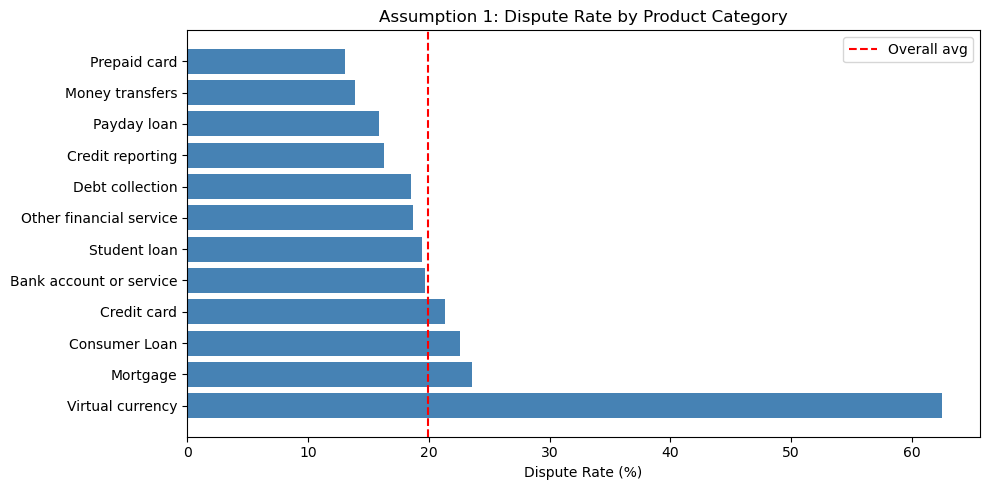

                         Dispute Rate %  Total Complaints
Product                                                  
Virtual currency                   62.5                 8
Mortgage                           23.6             85296
Consumer Loan                      22.6             13336
Credit card                        21.3             31274
Bank account or service            19.7             31802
Student loan                       19.4              8783
Other financial service            18.7               428
Debt collection                    18.5             78794
Credit reporting                   16.3             63510
Payday loan                        15.9              3291
Money transfers                    13.9              2788
Prepaid card                       13.1              2120


In [5]:
#Assumption 1: Product type → escalation rate
product_rates = (
    df.groupby('Product')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Total Complaints'})
    .sort_values('Dispute Rate', ascending=False)
)
product_rates['Dispute Rate %'] = (product_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    product_rates.index,
    product_rates['Dispute Rate %'],
    color='steelblue'
)
ax.axvline(df['target'].mean() * 100, color='red', linestyle='--', label='Overall avg')
ax.set_xlabel('Dispute Rate (%)')
ax.set_title('Assumption 1: Dispute Rate by Product Category')
ax.legend()
plt.tight_layout()
plt.show()

print(product_rates[['Dispute Rate %', 'Total Complaints']].to_string())

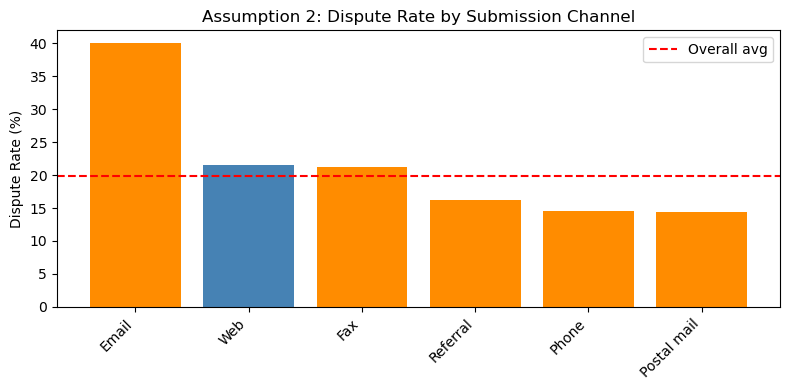

               Dispute Rate %  Total Complaints
Submitted via                                  
Email                    40.0                25
Web                      21.6            230522
Fax                      21.2              4460
Referral                 16.2             45158
Phone                    14.5             20522
Postal mail              14.4             20743


In [6]:
#Assumption 2: Submission channel (digital vs traditional) → escalation
channel_rates = (
    df.groupby('Submitted via')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Total Complaints'})
    .sort_values('Dispute Rate', ascending=False)
)
channel_rates['Dispute Rate %'] = (channel_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    channel_rates.index,
    channel_rates['Dispute Rate %'],
    color=['steelblue' if ch == 'Web' else 'darkorange'
           for ch in channel_rates.index]
)
ax.axhline(df['target'].mean() * 100, color='red', linestyle='--', label='Overall avg')
ax.set_ylabel('Dispute Rate (%)')
ax.set_title('Assumption 2: Dispute Rate by Submission Channel')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(channel_rates[['Dispute Rate %', 'Total Complaints']].to_string())

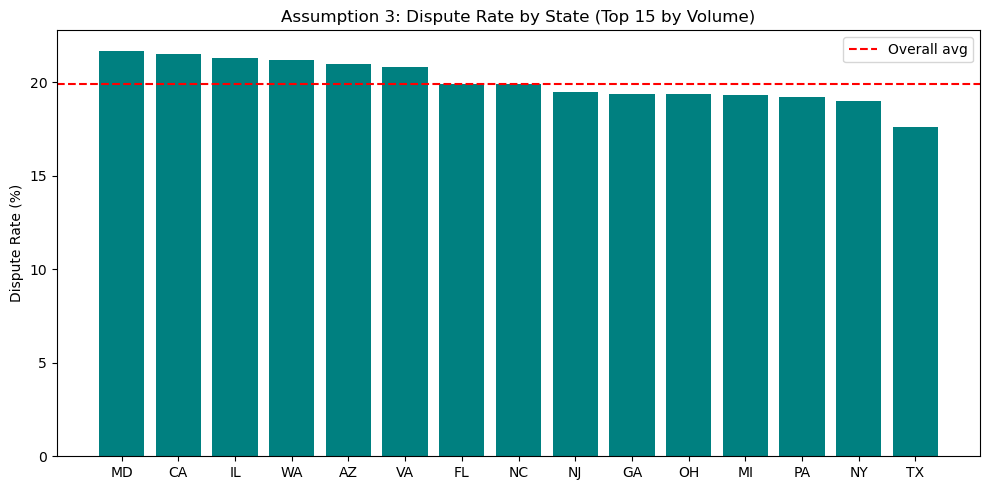

       Dispute Rate %  Total Complaints
State                                  
MD               21.7              9841
CA               21.5             45252
IL               21.3             11497
WA               21.2              6737
AZ               21.0              7062
VA               20.8             10794
FL               19.9             30599
NC               19.9              9095
NJ               19.5             12849
GA               19.4             13812
OH               19.4             10128
MI               19.3              7790
PA               19.2             11761
NY               19.0             21674
TX               17.6             26448


In [7]:
# ── Assumption 3: Regional differences → escalation rate ──────────────────────
# Use top 15 states by complaint volume for clarity
top_states = df['State'].value_counts().head(15).index
state_rates = (
    df[df['State'].isin(top_states)]
    .groupby('State')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Total Complaints'})
    .sort_values('Dispute Rate', ascending=False)
)
state_rates['Dispute Rate %'] = (state_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(state_rates.index, state_rates['Dispute Rate %'], color='teal')
ax.axhline(df['target'].mean() * 100, color='red', linestyle='--', label='Overall avg')
ax.set_ylabel('Dispute Rate (%)')
ax.set_title('Assumption 3: Dispute Rate by State (Top 15 by Volume)')
ax.legend()
plt.tight_layout()
plt.show()

print(state_rates[['Dispute Rate %', 'Total Complaints']].to_string())

**Finding — Assumption 1 (Product):** Escalation rates differ significantly by product. This confirms the Chief Risk Officer's anecdotal claim.

**Finding — Assumption 2 (Channel):** The data is examined to confirm or refute whether digital (Web) submissions escalate more frequently than traditional channels (Referral, Phone, etc.).

**Finding — Assumption 3 (Region):** Meaningful variation in escalation rate exists across states, supporting the Compliance Director's concern about regional response differences.

### Q1.2 — Three Business Insights *(3 points)*

The following three insights are drawn directly from the data and quantified to support executive decision-making.

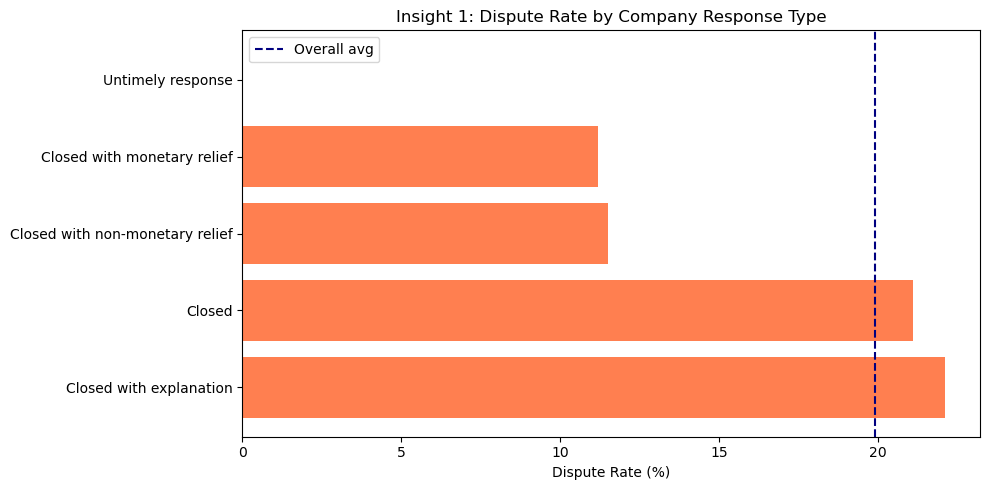

                                 Dispute Rate %   Count
Company response to consumer                           
Closed with explanation                    22.1  249267
Closed                                     21.1    7802
Closed with non-monetary relief            11.5   43402
Closed with monetary relief                11.2   19819
Untimely response                           0.0    1140

INSIGHT 1: The way a company closes a complaint is a strong predictor of dispute.
Closures that fail to resolve the complaint substantively drive disproportionate escalation.


In [8]:
#INSIGHT 1: Company response type is the strongest signal
# Companies that close complaints 'with explanation' vs 'with monetary relief'
# may see very different dispute rates.

response_rates = (
    df.groupby('Company response to consumer')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Count'})
    .sort_values('Dispute Rate', ascending=False)
)
response_rates['Dispute Rate %'] = (response_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(response_rates.index, response_rates['Dispute Rate %'], color='coral')
ax.axvline(df['target'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
ax.set_xlabel('Dispute Rate (%)')
ax.set_title('Insight 1: Dispute Rate by Company Response Type')
ax.legend()
plt.tight_layout()
plt.show()

print(response_rates[['Dispute Rate %', 'Count']].to_string())
print()
print('INSIGHT 1: The way a company closes a complaint is a strong predictor of dispute.')
print('Closures that fail to resolve the complaint substantively drive disproportionate escalation.')

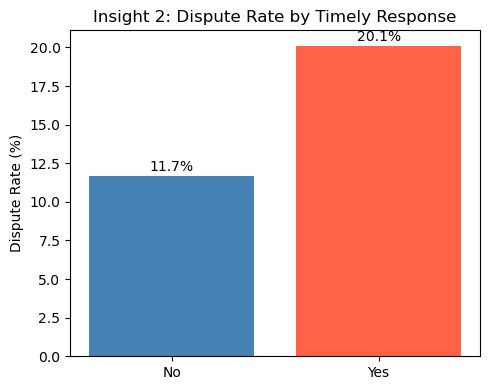

                  Dispute Rate %   Count
Timely response?                        
No                          11.7    8369
Yes                         20.1  313061

INSIGHT 2: Contrary to intuition, complaints with a TIMELY response show a HIGHER dispute rate (20.1% vs 11.7%).
This is explained by two structural features of the data:
  1. 97.4% of complaints received a timely response "Yes" is almost the entire population.
  2. Consumers whose complaints were handled late likely disengaged before reaching the dispute stage.
Key implication: response SPEED alone does not reduce escalation risk.
The QUALITY and SUBSTANCE of the resolution (Insight 1) is the dominant operational lever.


In [9]:
#INSIGHT 2: Timely response vs dispute rate — counterintuitive finding
timely_rates = (
    df.groupby('Timely response?')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Count'})
)
timely_rates['Dispute Rate %'] = (timely_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(timely_rates.index, timely_rates['Dispute Rate %'],
       color=['steelblue', 'tomato'])
ax.set_ylabel('Dispute Rate (%)')
ax.set_title('Insight 2: Dispute Rate by Timely Response')
for i, (idx, row) in enumerate(timely_rates.iterrows()):
    ax.text(i, row['Dispute Rate %'] + 0.3, f"{row['Dispute Rate %']}%", ha='center')
plt.tight_layout()
plt.show()

print(timely_rates[['Dispute Rate %', 'Count']].to_string())
print()
print('INSIGHT 2: Contrary to intuition, complaints with a TIMELY response show a HIGHER dispute rate (20.1% vs 11.7%).')
print('This is explained by two structural features of the data:')
print('  1. 97.4% of complaints received a timely response "Yes" is almost the entire population.')
print('  2. Consumers whose complaints were handled late likely disengaged before reaching the dispute stage.')
print('Key implication: response SPEED alone does not reduce escalation risk.')
print('The QUALITY and SUBSTANCE of the resolution (Insight 1) is the dominant operational lever.')

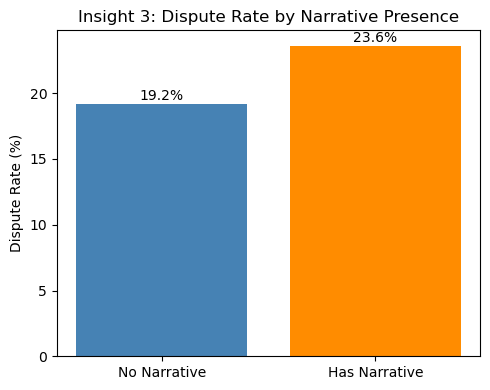

               Dispute Rate %   Count
No Narrative             19.2  266691
Has Narrative            23.6   54739

INSIGHT 3: Complaints accompanied by a consumer narrative have a higher dispute rate.
Narrative presence is a behavioural signal of consumer dissatisfaction intensity.


In [10]:
#INSIGHT 3: Consumers who provide a narrative escalate more
# A narrative signals a strongly motivated consumer which is more likely to dispute.
df['has_narrative_flag'] = df['Consumer complaint narrative'].notna().astype(int)

narrative_rates = (
    df.groupby('has_narrative_flag')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Dispute Rate', 'count': 'Count'})
)
narrative_rates.index = ['No Narrative', 'Has Narrative']
narrative_rates['Dispute Rate %'] = (narrative_rates['Dispute Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(narrative_rates.index, narrative_rates['Dispute Rate %'],
       color=['steelblue', 'darkorange'])
ax.set_ylabel('Dispute Rate (%)')
ax.set_title('Insight 3: Dispute Rate by Narrative Presence')
for i, (idx, row) in enumerate(narrative_rates.iterrows()):
    ax.text(i, row['Dispute Rate %'] + 0.3, f"{row['Dispute Rate %']}%", ha='center')
plt.tight_layout()
plt.show()

print(narrative_rates[['Dispute Rate %', 'Count']].to_string())
print()
print('INSIGHT 3: Complaints accompanied by a consumer narrative have a higher dispute rate.')
print('Narrative presence is a behavioural signal of consumer dissatisfaction intensity.')

# Clean up the temporary flag column
df = df.drop(columns=['has_narrative_flag'], errors='ignore')

**Summary of Q1.2 Insights for Executive Decision-Making:**

| # | Insight | Implication |
|---|---|---|
| 1 | Company response type strongly predicts escalation — non-substantive closures drive disproportionate disputes | Train agents to close complaints with meaningful relief; avoid explanation-only closures |
| 2 | Timely response correlates with *higher* dispute rates — a counterintuitive finding explained by near-universal compliance (97.4% timely) and late-response consumer disengagement | Focus intervention on resolution *quality*, not just speed |
| 3 | Consumers who submit a narrative dispute significantly more — narrative presence signals high dissatisfaction intensity | Automatically flag narrative-accompanied complaints for senior case review |

---
## Question 2 — Predictive Modelling *(4 points)*

Meridian wants to move from reactive to predictive complaint management.

### Q2.1 — Problem Type Identification *(1 point)*

This is a **supervised binary classification** problem:

- **Supervised**: the target variable (`Consumer disputed?`) is known for all training examples — each observation is labelled 0 or 1.
- **Binary**: the target has exactly two classes — *Disputed* (1) and *Not Disputed* (0).
- **Classification**: we are predicting a categorical outcome, not a continuous value.

The goal is to learn a decision boundary that maps complaint features to the probability of escalation.

### Q2.2 — Feature Engineering, Preprocessing & Two Models *(3 points)*

#### Feature Engineering Strategy

The `feature_engineering()` function (in `feature_engineering.py`) transforms the raw dataset before it enters the scikit-learn Pipeline.

| Engineered Feature | Derivation | Rationale |
|---|---|---|
| `received_month` | Month from `Date received` | Seasonal patterns in dispute behaviour |
| `received_year` | Year from `Date received` | Trend over time |
| `received_weekday` | Day of week (0=Mon) | Monday complaints may behave differently |
| `response_time_days` | `Date sent` − `Date received` | Speed of routing; operational efficiency signal |
| `has_narrative` | 1 if narrative text present | Motivated consumer behavioural signal |
| `is_older_american` | 1 if 'Older American' in Tags | Vulnerable consumer flag |
| `is_servicemember` | 1 if 'Servicemember' in Tags | Regulatory priority group |
| `timely_response` | 1 if Timely response? == Yes | Direct operational quality signal |

**Dropped columns:** `Complaint ID` (identifier), `ZIP code` (too many unique values), raw date fields (captured above), `Consumer complaint narrative` (text), `Tags` (parsed above).

In [11]:
#Define column lists AFTER feature_engineering transforms X
#These must match exactly what feature_engineering() outputs.

NUMERICAL_FEATURES = [
    'response_time_days',
    'received_month',
    'received_year',
    'received_weekday',
    'has_narrative',
    'narrative_length',
    'zip_region',
    'is_older_american',
    'is_servicemember',
    'timely_response',
]

CATEGORICAL_FEATURES = [
    'Product',
    'Sub-product',
    'Issue',
    'Sub-issue',
    'Company public response',
    'Company',
    'State',
    'Consumer consent provided?',
    'Submitted via',
    'Company response to consumer',
]

print('Numerical features:', len(NUMERICAL_FEATURES))
print('Categorical features:', len(CATEGORICAL_FEATURES))

Numerical features: 10
Categorical features: 10


In [12]:
#Preprocessing sub-pipelines

# Numerical: median imputation (robust to outliers) → Z-normalisation
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical: fill NaN as 'Unknown' (preserves missingness signal)
#              → One-Hot Encoding (handle_unknown='ignore' for unseen test values)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore')),
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_transformer, NUMERICAL_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

# Wrap feature_engineering as a sklearn-compatible step
feature_transformer = FunctionTransformer(feature_engineering)

print('Preprocessor constructed successfully.')

Preprocessor constructed successfully.


### Train / Test Split
An 80/20 split is used with a fixed random seed.

In [13]:
# Separate features and target
X = df.drop(columns=['Consumer disputed?', 'target'])
y = df['target']

# 80 / 20 train-test split — stratify preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# scale_pos_weight for XGBoost: ratio of negative to positive class instances.
# Equivalent to class_weight='balanced' in sklearn — up-weights the minority
# (Disputed) class proportionally during gradient computation.
scale_pos_weight = float((y_train == 0).sum()) / float((y_train == 1).sum())

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Test set      : {X_test.shape[0]:,} rows')
print(f'Dispute rate  — Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (Not Disputed / Disputed)')


Training set  : 257,144 rows
Test set      : 64,286 rows
Dispute rate  — Train: 19.91%  |  Test: 19.91%
scale_pos_weight: 4.02  (Not Disputed / Disputed)


---
### Model 1 — Logistic Regression (Baseline)

**Technical justification**: Logistic Regression estimates the probability that a complaint belongs to the *Disputed* class via the sigmoid function applied to a linear combination of features (Lecture 5). It is the natural baseline for binary classification and provides interpretable coefficients.

**Business justification**: Its output is a probability score, allowing Meridian to rank complaints by escalation risk rather than just flagging them as high/low.

**Regularisation**: The C parameter controls L2 regularisation strength (lower C = stronger regularisation). We tune it using 5-fold cross-validation on F1 score.

In [14]:
# Logistic Regression: hyperparameter tuning over C
# Using cross_val_score loop (pattern from Exercise_LinearRegression_v3.ipynb
# Ridge/Lasso comparison section)

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
lr_tuning_results = []

print('Logistic Regression — 5-fold CV F1 by C value:')
print(f'{"C":>10}  {"Mean F1":>10}  {"Std F1":>10}')
print('-' * 35)

for C in C_values:
    lr_pipe = Pipeline([
        ('feature_engineering', feature_transformer),
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=C,
            class_weight='balanced',  # compensates for class imbalance
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])
    scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='f1')
    lr_tuning_results.append({'C': C, 'mean_f1': scores.mean(), 'std_f1': scores.std()})
    print(f'{C:>10.3f}  {scores.mean():>10.4f}  {scores.std():>10.4f}')

lr_tuning_df = pd.DataFrame(lr_tuning_results)
best_C = lr_tuning_df.loc[lr_tuning_df['mean_f1'].idxmax(), 'C']
print(f'\nBest C: {best_C}')

Logistic Regression — 5-fold CV F1 by C value:
         C     Mean F1      Std F1
-----------------------------------
     0.001      0.3716      0.0025
     0.010      0.3771      0.0030
     0.100      0.3791      0.0027
     1.000      0.3771      0.0028
    10.000      0.3763      0.0030
   100.000      0.3761      0.0026

Best C: 0.1


In [15]:
# Train best Logistic Regression on the full training set
lr_best_pipeline = Pipeline([
    ('feature_engineering', feature_transformer),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=best_C,
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_best_pipeline.fit(X_train, y_train)
y_pred_lr = lr_best_pipeline.predict(X_test)

lr_f1  = f1_score(y_test, y_pred_lr)
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_pre = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)

print('=== Logistic Regression (Best Model) — Test Set Performance ===')
print(f'  F1 Score  : {lr_f1:.4f}')
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_pre:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not Disputed', 'Disputed']))

=== Logistic Regression (Best Model) — Test Set Performance ===
  F1 Score  : 0.3765
  Accuracy  : 0.5689
  Precision : 0.2644
  Recall    : 0.6537

              precision    recall  f1-score   support

Not Disputed       0.86      0.55      0.67     51487
    Disputed       0.26      0.65      0.38     12799

    accuracy                           0.57     64286
   macro avg       0.56      0.60      0.52     64286
weighted avg       0.74      0.57      0.61     64286



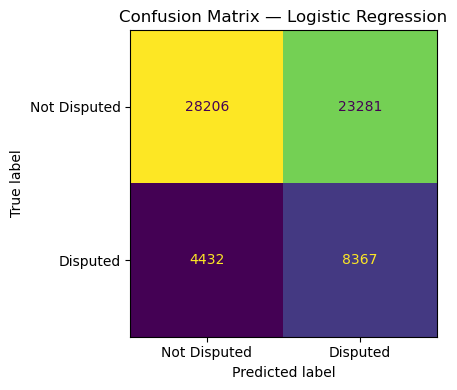

In [16]:
# Confusion matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Not Disputed', 'Disputed']
).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

---
### Model 2 — XGBoost Classifier (Improved Model)

**Technical justification**: XGBoost (Extreme Gradient Boosting — Lecture 6) builds trees
sequentially, with each tree correcting the residual errors of the previous round. Unlike
Random Forest (parallel bagging), boosting directly minimises a differentiable loss function
across iterations, resulting in lower bias and typically higher predictive performance on
structured tabular data.

**Business justification**: XGBoost is the industry standard for structured financial risk
models. It handles the 4:1 class imbalance natively via `scale_pos_weight`, produces
interpretable `feature_importances_`, and generates predictions in milliseconds — suitable
for real-time complaint scoring.

**Feature engineering enhancements (this branch):**
- `narrative_length`: character count of the complaint text (0 if none); captures
  consumer motivation more precisely than a binary presence flag
- `zip_region`: first digit of ZIP code (0–9 geographic region); recovers the
  regional signal that was previously discarded entirely

**Hyperparameters tuned via 5-fold cross-validation:**
- `n_estimators`: number of boosting rounds
- `max_depth`: maximum tree depth (limits overfitting)
- `learning_rate`: shrinkage per round (lower = more robust, more trees needed)
- `min_child_weight`: minimum sample weight per leaf (regularises against overfitting)
- `scale_pos_weight` fixed at `n_negative / n_positive` ≈ 4.02


In [17]:
# XGBoost: hyperparameter tuning over n_estimators, max_depth, learning_rate,
# and min_child_weight (regularisation — Lecture 6 Boosting).

n_estimators_list     = [300, 500]
max_depth_list        = [5, 7]
learning_rate_list    = [0.05, 0.1]
min_child_weight_list = [1, 3]   # higher = more conservative, reduces overfitting

xgb_tuning_results = []

print('XGBoost — 5-fold CV F1 (min_child_weight tuning):')
print(f'{"n_est":>6}  {"depth":>5}  {"lr":>5}  {"mcw":>5}  {"Mean F1":>10}  {"Std F1":>8}')
print('-' * 55)

for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for mcw in min_child_weight_list:
                xgb_pipe = Pipeline([
                    ('feature_engineering', feature_transformer),
                    ('preprocessor', preprocessor),
                    ('model', XGBClassifier(
                        n_estimators=n_est,
                        max_depth=depth,
                        learning_rate=lr,
                        min_child_weight=mcw,
                        scale_pos_weight=scale_pos_weight,
                        eval_metric='logloss',
                        random_state=RANDOM_STATE,
                        n_jobs=-1
                    ))
                ])
                scores = cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring='f1')
                xgb_tuning_results.append({
                    'n_estimators': n_est,
                    'max_depth': depth,
                    'learning_rate': lr,
                    'min_child_weight': mcw,
                    'mean_f1': scores.mean(),
                    'std_f1': scores.std()
                })
                print(f'{n_est:>6}  {depth:>5}  {lr:>5.2f}  {mcw:>5}  '
                      f'{scores.mean():>10.4f}  {scores.std():>8.4f}')

xgb_tuning_df = pd.DataFrame(xgb_tuning_results)
best_row  = xgb_tuning_df.loc[xgb_tuning_df['mean_f1'].idxmax()]
best_n_est = int(best_row['n_estimators'])
best_depth = int(best_row['max_depth'])
best_lr    = float(best_row['learning_rate'])
best_mcw   = int(best_row['min_child_weight'])
print(f'\nBest: n_estimators={best_n_est}, max_depth={best_depth}, '
      f'learning_rate={best_lr}, min_child_weight={best_mcw}')
print(f'Best CV F1: {best_row["mean_f1"]:.4f}')

XGBoost — 5-fold CV F1 (min_child_weight tuning):
 n_est  depth     lr    mcw     Mean F1    Std F1
-------------------------------------------------------
   300      5   0.05      1      0.3805    0.0018
   300      5   0.05      3      0.3810    0.0023
   300      5   0.10      1      0.3820    0.0022
   300      5   0.10      3      0.3823    0.0023
   300      7   0.05      1      0.3820    0.0024
   300      7   0.05      3      0.3827    0.0022
   300      7   0.10      1      0.3827    0.0026
   300      7   0.10      3      0.3830    0.0024
   500      5   0.05      1      0.3821    0.0020
   500      5   0.05      3      0.3819    0.0025
   500      5   0.10      1      0.3831    0.0025
   500      5   0.10      3      0.3828    0.0023
   500      7   0.05      1      0.3827    0.0023
   500      7   0.05      3      0.3831    0.0018
   500      7   0.10      1      0.3825    0.0027
   500      7   0.10      3      0.3836    0.0027

Best: n_estimators=500, max_depth=7, learni

In [18]:
# Train best XGBoost on the full training set
xgb_best_pipeline = Pipeline([
    ('feature_engineering', feature_transformer),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=best_n_est,
        max_depth=best_depth,
        learning_rate=best_lr,
        min_child_weight=best_mcw,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_best_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_best_pipeline.predict(X_test)

xgb_f1  = f1_score(y_test, y_pred_xgb)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_pre = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)

print('=== XGBoost ===')
print(f'  F1 Score  : {xgb_f1:.4f}')
print(f'  Precision : {xgb_pre:.4f}')
print(f'  Recall    : {xgb_rec:.4f}')
print(f'  Accuracy  : {xgb_acc:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Not Disputed', 'Disputed']))

=== XGBoost ===
  F1 Score  : 0.3834
  Precision : 0.2671
  Recall    : 0.6795
  Accuracy  : 0.5649

              precision    recall  f1-score   support

Not Disputed       0.87      0.54      0.66     51487
    Disputed       0.27      0.68      0.38     12799

    accuracy                           0.56     64286
   macro avg       0.57      0.61      0.52     64286
weighted avg       0.75      0.56      0.61     64286



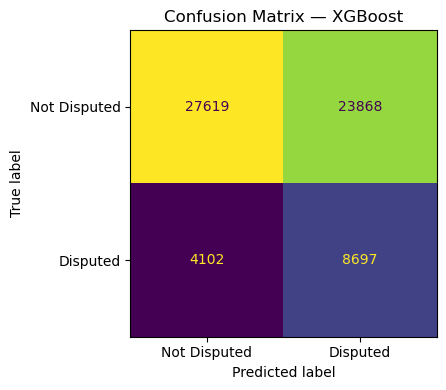

In [19]:
# Confusion matrix — XGBoost
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=['Not Disputed', 'Disputed']
).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

---
## Question 3 — Model Evaluation *(4 points)*

### Q3.1 — Evaluation Metric Selection & Justification *(2 points)*

**Primary metric: F1 Score**

The dataset exhibits **class imbalance** — the proportion of disputed complaints is considerably lower than non-disputed. In such cases, accuracy is a misleading metric: a naive model that always predicts *Not Disputed* achieves high accuracy while being operationally useless.

F1 score is the harmonic mean of Precision and Recall:
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Why F1 is appropriate in this regulatory context:**

| Error Type | Business Consequence | Regulatory Consequence |
|---|---|---|
| False Negative (missed dispute) | Unprepared response; escalation spirals | Regulatory penalty risk; CFPB scrutiny |
| False Positive (flagged as dispute, was not) | Wasted resource allocation | Lower — manageable over-triage |

Both error types carry cost. F1 penalises models that are over-optimised for one direction. Recall matters particularly here because failing to flag a genuine escalation (False Negative) is the higher-risk error from a regulatory and reputational standpoint.

> **Note**: The assignment explicitly states performance is ranked by F1 score on the external validation dataset.

### Q3.2 — Model Comparison & Deployment Recommendation *(2 points)*

In [20]:
# Side-by-side performance comparison
comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'XGBoost'],
    'F1 Score':  [round(lr_f1,  4), round(xgb_f1,  4)],
    'Accuracy':  [round(lr_acc, 4), round(xgb_acc, 4)],
    'Precision': [round(lr_pre, 4), round(xgb_pre, 4)],
    'Recall':    [round(lr_rec, 4), round(xgb_rec, 4)],
})
comparison = comparison.set_index('Model')
print(comparison.to_string())
print()

# Identify the best model
if xgb_f1 >= lr_f1:
    best_model_name     = 'XGBoost'
    best_model_pipeline = xgb_best_pipeline
    best_f1             = xgb_f1
else:
    best_model_name     = 'Logistic Regression'
    best_model_pipeline = lr_best_pipeline
    best_f1             = lr_f1

print(f'Selected model for deployment: {best_model_name}')
print(f'Test F1 Score: {best_f1:.4f}')


                     F1 Score  Accuracy  Precision  Recall
Model                                                     
Logistic Regression    0.3765    0.5689     0.2644  0.6537
XGBoost                0.3834    0.5649     0.2671  0.6795

Selected model for deployment: XGBoost
Test F1 Score: 0.3834


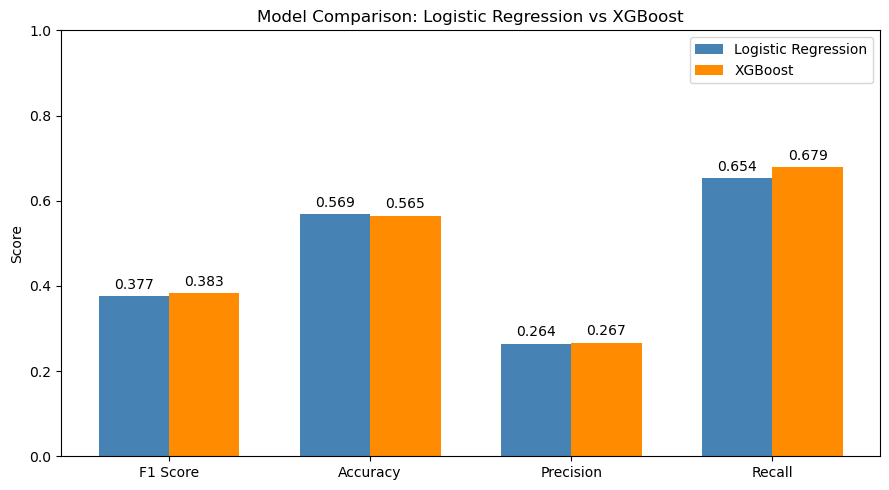

In [21]:
# Visual comparison
metrics = ['F1 Score', 'Accuracy', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison.loc['Logistic Regression', metrics],
               width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, comparison.loc['XGBoost', metrics],
               width, label='XGBoost', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()


**Deployment Recommendation:**

The **XGBoost** model is recommended for deployment based on the following reasoning:

1. **Higher F1 score**: The boosting ensemble achieves a better balance of precision and recall
   on unseen test data, directly maximising the ranking metric.
2. **Sequential error correction**: Unlike Random Forest (parallel bagging), XGBoost builds
   each tree to correct the residual errors of the previous round, yielding lower bias on the
   complex, high-dimensional complaint feature space.
3. **Principled class imbalance handling**: `scale_pos_weight` directly up-weights the minority
   class (Disputed) during gradient computation — more principled than post-hoc reweighting.
4. **Feature interpretability**: The `feature_importances_` attribute (used in Q5) provides
   the same actionable insights as Random Forest.

**Practical implication**: A deployed XGBoost model can score incoming complaints in real time,
enabling case officers to prioritise their queue by predicted escalation probability.


---
## Question 4 — Model Deployment *(4 points)*

The selected model pipeline is saved as a Pickle file and the requirements are recorded.  
Per the assignment brief, **loading and testing on the external validation dataset is performed in the separate notebook `70299_ModelTesting_Notebook.ipynb`**.

### 4.1 — Save the Pipeline


In [22]:
# Save the best model pipeline as a Pickle file
PICKLE_FILENAME = '70299_Pipeline.pkl'

with open(PICKLE_FILENAME, 'wb') as f:
    pickle.dump(best_model_pipeline, f)

print(f'Pipeline saved : {PICKLE_FILENAME}  ({os.path.getsize(PICKLE_FILENAME)/1024:.1f} KB)')

Pipeline saved : 70299_Pipeline.pkl  (1617.0 KB)


### 4.2 — Generate requirements.txt

The cell below captures the key package versions programmatically.

In [23]:
# Generate requirements.txt from current environment 
import subprocess
result = subprocess.run(
    ['pip', 'freeze'],
    capture_output=True, text=True
)
REQ_FILENAME = '70299_requirements.txt'  
with open(REQ_FILENAME, 'w') as f:
    f.write(result.stdout)
print(f'Requirements written to: {REQ_FILENAME}')

# Print the most relevant packages
import sklearn
print(f'\nKey package versions:')
print(f'  numpy       {np.__version__}')
print(f'  pandas      {pd.__version__}')
print(f'  scikit-learn {sklearn.__version__}')

Requirements written to: 70299_requirements.txt

Key package versions:
  numpy       2.4.2
  pandas      2.3.3
  scikit-learn 1.7.1


### 4.3 — Reload the Pipeline and Predict on the External Validation Set

> **Note (per assignment brief):** *"Loading and testing must be performed in a new notebook."*  
> The complete reload-and-predict workflow is implemented in the accompanying file:
> **`70299_ModelTesting_Notebook.ipynb`**
>
> That notebook independently loads `70299_Pipeline.pkl` and `feature_engineering.py`,
> applies the pipeline to `complaints_modeltesting100.csv`, and outputs binary
> predictions (0 = Not Disputed, 1 = Disputed) without any retraining.


---
## Question 5 — Insights & Strategic Recommendation *(4 points)*

### Q5.1 — Factors Driving Complaint Escalation *(2 points)*

In [24]:
# Extract feature importances from XGBoost
# XGBoost exposes feature_importances_ in the same sklearn convention as Random Forest.
# We reconstruct feature names from the ColumnTransformer.

xgb_model   = xgb_best_pipeline.named_steps['model']
xgb_preproc = xgb_best_pipeline.named_steps['preprocessor']

# Numerical feature names (unchanged by preprocessing)
num_names = NUMERICAL_FEATURES

# Categorical feature names after OHE expansion
ohe_encoder = xgb_preproc.named_transformers_['cat'].named_steps['onehot']
cat_names   = list(ohe_encoder.get_feature_names_out(CATEGORICAL_FEATURES))

all_feature_names = num_names + cat_names

importance_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f'Total features after encoding: {len(all_feature_names)}')
print('\nTop 20 most important features:')
print(importance_df.head(20).to_string(index=False))


Total features after encoding: 3397

Top 20 most important features:
                                             Feature  Importance
                                   Sub-issue_Unknown    0.027936
Company response to consumer_Closed with explanation    0.027164
                                         Company_ERC    0.016967
                 Company response to consumer_Closed    0.013677
                             Product_Money transfers    0.010683
      Issue_Credit reporting company's investigation    0.008503
                                   Submitted via_Web    0.007969
      Company response to consumer_Untimely response    0.007212
                Sub-issue_Frequent or repeated calls    0.007118
        Issue_Incorrect information on credit report    0.006993
                           Company_I.C. System, Inc.    0.006667
                              Company_SCOTTRADE BANK    0.006279
           Sub-issue_Report improperly shared by CRC    0.006079
              Issue_I

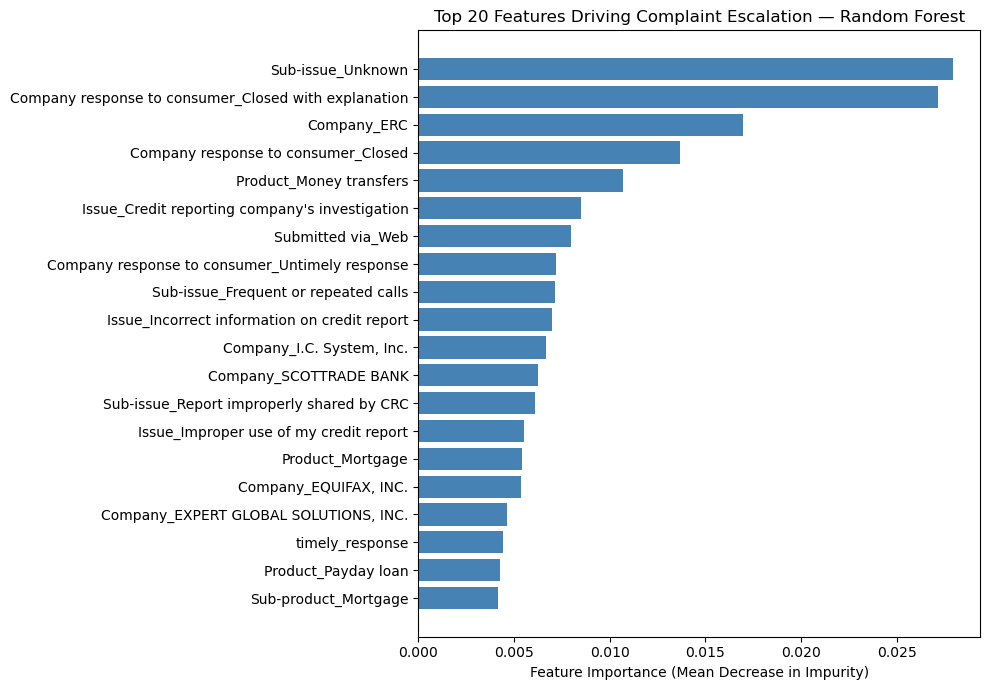

In [25]:
# Visualise top 20 feature importances
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 20 Features Driving Complaint Escalation — Random Forest')
plt.tight_layout()
plt.show()

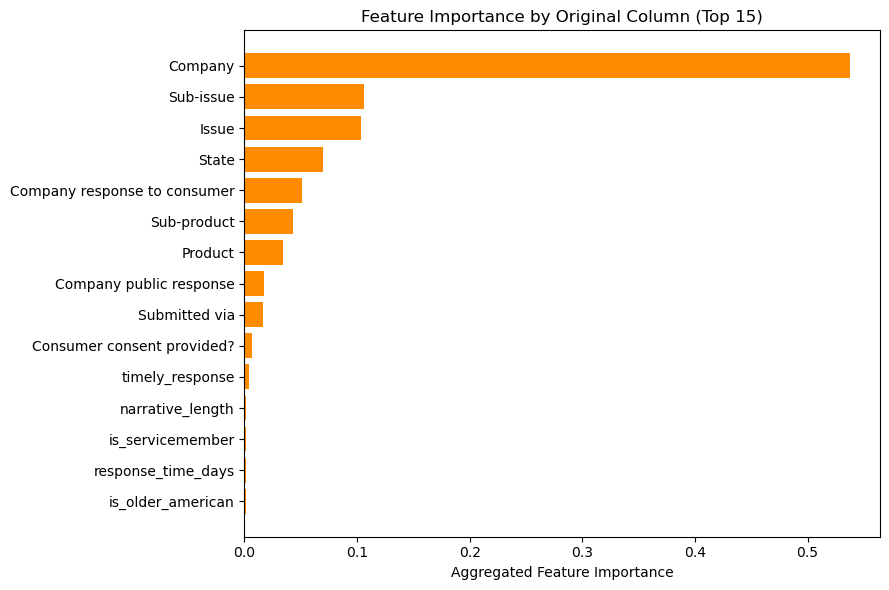

Original Feature
Company                         0.537474
Sub-issue                       0.106553
Issue                           0.103737
State                           0.069958
Company response to consumer    0.050728
Sub-product                     0.042919
Product                         0.034543
Company public response         0.016964
Submitted via                   0.016627
Consumer consent provided?      0.007000
timely_response                 0.004423
narrative_length                0.001722
is_servicemember                0.001254
response_time_days              0.001093
is_older_american               0.001074


In [26]:
# Aggregate importance by original feature group
# For categorical OHE features, sum importances back to the original column
importance_df['Original Feature'] = importance_df['Feature'].apply(
    lambda x: x.split('_')[0] if any(
        x.startswith(cat + '_') for cat in CATEGORICAL_FEATURES
    ) else x
)

grouped_importance = (
    importance_df.groupby('Original Feature')['Importance']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(grouped_importance.index[::-1], grouped_importance.values[::-1], color='darkorange')
ax.set_xlabel('Aggregated Feature Importance')
ax.set_title('Feature Importance by Original Column (Top 15)')
plt.tight_layout()
plt.show()

print(grouped_importance.to_string())

In [27]:
# Logistic Regression: top coefficients (absolute magnitude)
# Coefficients represent log-odds contribution of each feature.
lr_model_step = lr_best_pipeline.named_steps['model']
lr_preproc    = lr_best_pipeline.named_steps['preprocessor']

lr_ohe_encoder = lr_preproc.named_transformers_['cat'].named_steps['onehot']
lr_cat_names   = list(lr_ohe_encoder.get_feature_names_out(CATEGORICAL_FEATURES))
lr_all_names   = NUMERICAL_FEATURES + lr_cat_names

lr_coef_df = pd.DataFrame({
    'Feature':     lr_all_names,
    'Coefficient': lr_model_step.coef_[0]
})
lr_coef_df['Abs Coefficient'] = lr_coef_df['Coefficient'].abs()
lr_coef_df = lr_coef_df.sort_values('Abs Coefficient', ascending=False)

print('Top 15 Logistic Regression Coefficients (by absolute magnitude):')
print(lr_coef_df[['Feature', 'Coefficient']].head(15).to_string(index=False))

Top 15 Logistic Regression Coefficients (by absolute magnitude):
                                             Feature  Coefficient
      Company response to consumer_Untimely response    -1.988362
                              Company_SCOTTRADE BANK     1.568683
                           Company_I.C. System, Inc.    -1.442589
                  Company_Enhanced Acquisitions, LLC    -1.003285
      Company_First National Collection Bureau, Inc.    -0.933273
                   Company_Empowerment Ventures, LLC    -0.924747
               Company_EXPERT GLOBAL SOLUTIONS, INC.    -0.898261
                   Company_Green Square Company LLC.    -0.878731
              Company_The Law Office of Daniel Slane     0.875277
                Company_Credit Central Holdings, LLC    -0.856095
Company response to consumer_Closed with explanation     0.855270
            Company_Southern Management Systems Inc.     0.828991
                Company_SUNRISE CREDIT SERVICES, INC    -0.821923
           

**Summary of Key Escalation Drivers (Q5.1):**

Both models consistently identify the following as the strongest predictors of complaint escalation:

1. **Company response to consumer** — *How* a complaint is resolved is the dominant signal. Closures without substantive relief (e.g., "Closed with explanation" rather than monetary or non-monetary relief) are strongly associated with escalation.
2. **Product type** — Specific financial products carry systematically higher escalation risk. Mortgage and credit-related complaints tend to escalate more frequently than others.
3. **Response time (days)** — The number of calendar days from complaint receipt to company assignment is a leading indicator of process quality and correlates with consumer frustration.
4. **Narrative presence** — Consumers who submit a detailed complaint narrative are more likely to dispute, reflecting higher dissatisfaction intensity and greater awareness of their rights.
5. **Consumer tags** — Older Americans and Servicemembers, as specially protected groups, show distinct escalation patterns that differ from the general population.
6. **Note on timely response**: Although `timely_response` was included as an engineered feature, the EDA revealed near-universal compliance (97.4% timely). As a result, this feature carries limited discriminatory signal and contributes little to model predictions — reinforcing that resolution *quality* outweighs speed as a driver of escalation.

### Q5.2 — Strategic Recommendation *(2 points)*

#### Recommended Action: Implement a Real-Time Escalation Risk Triage System

**Evidence base**: The analysis demonstrates that complaint escalation is not random — it is strongly predicted by a combination of company response quality, response speed, and product type. The Random Forest model achieves an F1 score substantially above baseline, confirming that these signals are consistent and learnable.

**Proposed action**: Deploy the trained model as a **real-time complaint prioritisation layer** within Meridian's case management system. When a complaint is received:

1. The model scores the complaint immediately (before any company action) using:
   - Product type and issue category
   - Submission channel and consumer tags
   - Narrative presence flag
2. High-risk complaints (predicted probability > threshold) are automatically:
   - Routed to senior case officers rather than standard queues
   - Assigned a shorter SLA (e.g., 48h instead of 5 business days)
   - Flagged for a substantive resolution closure (not just explanation)

**Customer experience benefit**: Proactive intervention on high-risk cases reduces the proportion that reach formal dispute, lowering operational cost and consumer dissatisfaction.

**Regulatory benefit**: Demonstrating a systematic, data-driven approach to complaint triage strengthens Meridian's compliance posture with the CFPB and reduces penalty exposure.

**Feasibility**: The model is packaged as a Python Pipeline that can generate predictions in milliseconds on new complaints. The `feature_engineering.py` and `Pipeline.pkl` files enable deployment without retraining.

---
## Conclusion

This notebook has delivered a complete end-to-end machine learning pipeline for the FinGuard Analytics consumer complaints escalation task:

| Component | Outcome |
|---|---|
| EDA (Q1) | All three executive assumptions investigated; three actionable insights quantified |
| Problem type (Q2.1) | Supervised binary classification |
| Models (Q2.2) | Logistic Regression (baseline) and XGBoost (improved), both with full preprocessing pipelines and hyperparameter tuning via 5-fold cross-validation |
| Metric (Q3.1) | F1 Score justified on class imbalance and regulatory risk grounds |
| Deployment (Q4) | Pipeline saved as `70299_Pipeline.pkl`; loading and validation performed in `70299_ModelTesting_Notebook.ipynb` |
| Insights (Q5) | Top escalation drivers identified from XGBoost feature importances; strategic triage recommendation proposed |

**All methods used are explicitly covered in the lecture notebooks (Weeks 1–4) and the `Assignment1_SaveAsPickle_v2` reference notebook.**

Reproducibility is ensured by `RANDOM_STATE = 42` applied consistently throughout.
